In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [3]:
# ===================== 1. Загрузка данных =====================
train_df = pd.read_csv("train.csv")
test_features = pd.read_csv("test_features.csv")

feature_columns = [col for col in train_df.columns if col not in ["patient_id", "prediction"]]

# В данных есть пропуски, поэтому заполняем их медианами из обучающей выборки
medians = train_df[feature_columns].median()
train_df[feature_columns] = train_df[feature_columns].fillna(medians)
test_features[feature_columns] = test_features[feature_columns].fillna(medians)

X = train_df[feature_columns].values.astype(np.float32)
y = train_df["prediction"].values.astype(np.float32).reshape(-1, 1)

X_submission = test_features[feature_columns].values.astype(np.float32)
submission_patient_ids = test_features["patient_id"].values

print(f"Признаков: {X.shape[1]}, Объектов: {X.shape[0]}")
print(f"Тестовых объектов для предсказания: {X_submission.shape[0]}")

Признаков: 17, Объектов: 800
Тестовых объектов для предсказания: 200


In [4]:
# ===================== 2. Разбиение на train/test =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# ===================== 3. Нормализация признаков =====================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_submission = scaler.transform(X_submission)

In [6]:
# ===================== 4. Преобразование в тензоры =====================
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test)
X_submission_t = torch.tensor(X_submission)

In [7]:
# ===================== 5. DataLoader =====================
batch_size = 32
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# ===================== 6. Определение модели FFN =====================
class Task1FFN(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.fc1 = nn.Linear(input_dim, 64)
    self.fc2 = nn.Linear(64, 32)
    self.fc3 = nn.Linear(32, 1) 
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(0.2)

  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.relu(self.fc2(x))
    x = self.fc3(x)         
    return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Task1FFN(X_train.shape[1]).to(device)

In [9]:
# ===================== 7. Функция потерь и оптимизатор =====================
criterion = nn.BCEWithLogitsLoss()   # устойчивая комбинация Sigmoid + BCELoss
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
# ===================== 8. Цикл обучения =====================
epochs = 100
train_losses, test_losses = [], []

for epoch in range(epochs):
    # --- Train ---
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    epoch_test_loss = val_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Train Loss: {epoch_train_loss:.4f}, Test Loss: {epoch_test_loss:.4f}")

Epoch 20/100 — Train Loss: 0.0781, Test Loss: 0.1480
Epoch 40/100 — Train Loss: 0.0344, Test Loss: 0.1680
Epoch 60/100 — Train Loss: 0.0305, Test Loss: 0.2248
Epoch 80/100 — Train Loss: 0.0179, Test Loss: 0.2303
Epoch 100/100 — Train Loss: 0.0136, Test Loss: 0.2461


In [ ]:
# ===================== 9. Оценка модели =====================
model.eval()
y_pred_prob = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)         
        y_pred_prob.extend(probs.cpu().numpy().flatten())
        y_true.extend(y_batch.numpy().flatten())

y_pred_prob = np.array(y_pred_prob)
y_true = np.array(y_true)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

In [12]:
# ===================== 10. Метрики =====================
# Accuracy — доля правильных ответов
# Precision — из всех предсказанных положительных, сколько действительно положительных
# Recall — из всех реальных положительных, сколько мы нашли
# F1-score — гармоническое среднее между Precision и Recall (полезно при дисбалансе)
# ROC-AUC — площадь под ROC-кривой; показывает, насколько хорошо модель разделяет классы (0.5 — случайно, 1.0 — идеально)

print("\n" + "="*50)
print("Оценка на тестовой выборке:")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_true, y_pred_class):.4f}")
print(f"Precision: {precision_score(y_true, y_pred_class):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred_class):.4f}")
print(f"F1-score:  {f1_score(y_true, y_pred_class):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_true, y_pred_prob):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_class))


Оценка на тестовой выборке:
Accuracy:  0.9375
Precision: 0.8800
Recall:    0.7586
F1-score:  0.8148
ROC-AUC:   0.9824

Confusion Matrix:
[[128   3]
 [  7  22]]


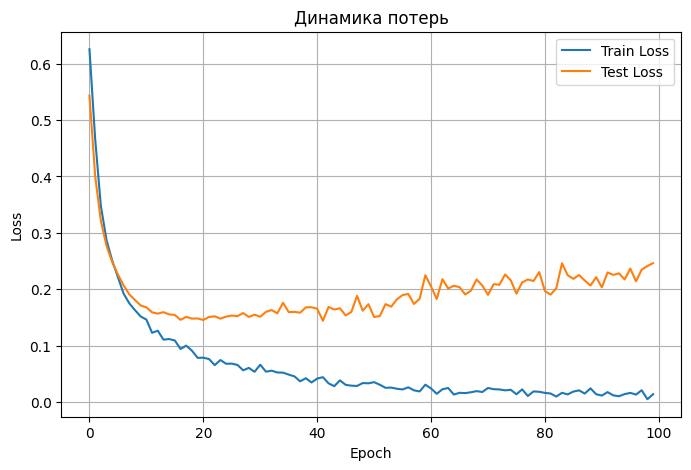

In [13]:
# ===================== 11. График потерь =====================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Динамика потерь')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# ===================== 12. Предсказания для test_features.csv =====================
model.eval()

with torch.no_grad():
    outputs = model(X_submission_t.to(device))
    probabilities = torch.sigmoid(outputs)
    predictions = (probabilities >= 0.5).int().cpu().numpy().flatten()

submission = pd.DataFrame({
    "patient_id": submission_patient_ids,
    "prediction": predictions
})

import os
os.makedirs("outputs", exist_ok=True)
submission.to_csv("outputs/task1_predictions.csv", index=False)

submission.head()

,patient_id,prediction
0,2,0
1,3,0
2,8,0
3,18,0
4,19,0
